In [ ]:
# !pip install hampel

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.7/78.7 kB 5.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for hampel: filename=hampel-1.0.2-cp310-cp310-linux_x86_64.whl size=208983 sha256=3513f3a75b9876de5e1d21ee396ddb861a4c1168a10baf0f6152a58cab5e967e
  Stored in directory: /root/.cache/pip/wheels/0e/c3/3c/8a9f55c3de0b09faf919393d4c6f09b11b7421dcaa7243b820
Successfully built hampel


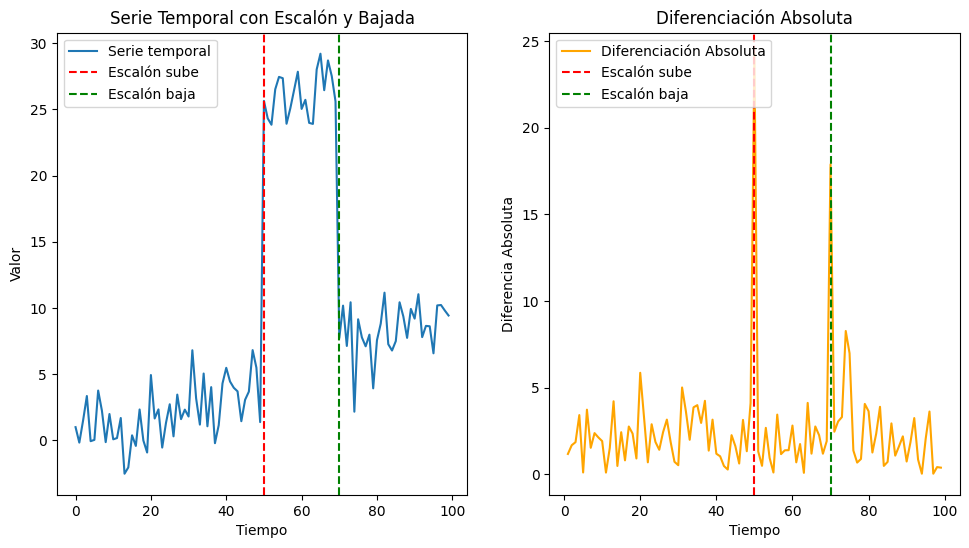

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Fijar semilla
np.random.seed(42)

# Crear una serie con tendencia, un escalón, y un descenso del escalón en t=50 y t=70
t_complex = np.arange(0, 100, 1)

# Tendencia lineal
trend_complex = 0.1 * t_complex

# Ruido normal
noise_complex = np.random.normal(0, 2, size=len(t_complex))

# Crear la serie con escalón en t=50 y bajada del escalón en t=70
series_complex = trend_complex + noise_complex
series_complex[50:] += 20  # Aplicar el escalón en t=50
series_complex[70:] -= 20  # Reducir el escalón a partir de t=70

# Diferenciación absoluta
diff_series_complex = np.abs(np.diff(series_complex))

# Graficamos la serie original y sus transformadas (diferenciación absoluta y relativa)
plt.figure(figsize=(18, 6))

# Serie temporal original con escalón y bajada
plt.subplot(1, 3, 1)
plt.plot(t_complex, series_complex, label="Serie temporal")
plt.axvline(x=50, color='r', linestyle='--', label="Escalón sube")
plt.axvline(x=70, color='g', linestyle='--', label="Escalón baja")
plt.title("Serie Temporal con Escalón y Bajada")
plt.xlabel("Tiempo")
plt.ylabel("Valor")
plt.legend(loc='upper left')

# Diferenciación absoluta
plt.subplot(1, 3, 2)
plt.plot(t_complex[1:], diff_series_complex, label="Diferenciación Absoluta", color='orange')
plt.axvline(x=50, color='r', linestyle='--', label="Escalón sube")
plt.axvline(x=70, color='g', linestyle='--', label="Escalón baja")
plt.title("Diferenciación Absoluta")
plt.xlabel("Tiempo")
plt.ylabel("Diferencia Absoluta")
plt.legend(loc='upper left')

In [3]:
from bokeh.plotting import figure, show, output_notebook
from bokeh.models import ColumnDataSource
from bokeh.models.tools import BoxSelectTool
import numpy as np
from scipy.signal import medfilt
from hampel import hampel

# Configurar Bokeh para que funcione en Google Colab
output_notebook()

# Fijar la semilla para reproducibilidad
np.random.seed(42)

# Generar una señal temporal con duración de escalones aleatoria
num_steps = 50  # Número de pasos escalonados
amplitude_range = (0, 1)  # Normalizar amplitud entre 0 y 1
step_duration_range = (25, 500)  # Rango de duración de los escalones

# Generar valores escalonados aleatorios y duraciones aleatorias
steps = np.random.uniform(amplitude_range[0], amplitude_range[1], size=num_steps)
durations = np.random.randint(step_duration_range[0], step_duration_range[1], size=num_steps)

# Construir la señal con duraciones aleatorias
signal = np.hstack([np.full(duration, step) for step, duration in zip(steps, durations)])

# Crear un eje temporal
time = np.arange(len(signal))

# Introducir ruido al 25% de los datos
noise_fraction = 0.25  # Proporción de la señal con ruido
num_noisy_points = int(len(signal) * noise_fraction)  # Número de puntos con ruido
noise_indices = np.random.choice(len(signal), num_noisy_points, replace=False)  # Índices aleatorios para el ruido
noise = np.random.normal(0, 0.1, size=num_noisy_points)  # Ruido gaussiano con media 0 y desviación estándar 0.1
signal_with_noise = signal.copy()
signal_with_noise[noise_indices] += noise  # Agregar ruido a los puntos seleccionados

# Aplicar filtro de la media
# Tamaño de la ventana del filtro
##################
window_size = 3  #
##################

filtered_signal = np.convolve(signal_with_noise, np.ones(window_size) / window_size, mode='same')

# Aplicar filtro de la mediana
median_filtered_signal = medfilt(signal_with_noise, kernel_size=window_size)  # Tamaño de ventana 5

# Filtro Hampel
hampel_filtered_signal = hampel(signal_with_noise, window_size=window_size)

# Crear un DataSource para Bokeh
source = ColumnDataSource(data={
    'time': time,
    'signal': signal_with_noise,
    'filtered': filtered_signal,
    'original': signal,
    'median_filtered': median_filtered_signal,
    'hampel': hampel_filtered_signal.filtered_data,
})

# Función para crear gráficos
def create_plot(title, y_column, legend_label, color, alpha, line_dash="solid"):
    p = figure(title=title, x_axis_label="Tiempo", y_axis_label="Amplitud",
               width=800, height=300, tools="pan,wheel_zoom,box_zoom,reset,save")
    p.add_tools(BoxSelectTool())
    p.line('time', y_column, source=source, line_width=1.5, color=color,
           legend_label=legend_label, alpha=alpha, line_dash=line_dash)
    p.line('time', 'original', source=source, line_width=1.5, color='blue',
           legend_label="Original", alpha=1, line_dash="solid")
    p.legend.location = "top_left"
    p.grid.grid_line_alpha = 0.3
    return p

  # Crear y mostrar gráficos
show(create_plot("Señal Temporal",
                 y_column='original', legend_label="Original", color='black', alpha=0.5))
show(create_plot("Señal Temporal con Ruido",
                 y_column='signal', legend_label="Con ruido", color='black', alpha=0.5))
show(create_plot(f"Señal Temporal con Ruido y Filtro de la Media w_size:{window_size}",
                 y_column='filtered', legend_label="Filtrada (Media)", color='black', alpha=0.5))
show(create_plot(f"Señal Temporal con Ruido y Filtro de la Mediana w_size:{window_size}",
                 y_column='median_filtered', legend_label="Filtrada (Mediana)", color='green', alpha=0.8))
show(create_plot(f"Señal Temporal con Ruido y Filtro Hampel w_size:{window_size}",
                 y_column='hampel', legend_label="Filtrada (Hampel)", color='green', alpha=0.8))


Loading BokehJS ...

In [ ]:
from bokeh.plotting import figure, show, output_notebook
from bokeh.io import push_notebook
import numpy as np

# Cargar Bokeh en el notebook
output_notebook()

# Fijar la semilla para reproducibilidad
np.random.seed(42)

# Generar datos originales con ruido
signal = np.sin(np.linspace(0, 10, 100))
signal_with_noise = np.sin(np.linspace(0, 10, 100)) + np.random.normal(0, 0.1, 100)

# Agregar outliers al dataset
for index, value in zip([20, 40, 60, 80], [2.0, -1.9, 2.1, -0.5]):
    signal_with_noise[index] = value

# Crear un gráfico con Bokeh
time = np.linspace(0, 10, 100)

# Aplicar filtro de la media
# Tamaño de la ventana del filtro
##################
window_size = 9  #
##################

filtered_signal = np.convolve(signal_with_noise, np.ones(window_size) / window_size, mode='same')

# Aplicar filtro de la mediana
median_filtered_signal = medfilt(signal_with_noise, kernel_size=window_size)  # Tamaño de ventana 5

# Filtro Hampel
hampel_filtered_signal = hampel(signal_with_noise, window_size=window_size)

# Crear un DataSource para Bokeh
source = ColumnDataSource(data={
    'time': time,
    'signal': signal_with_noise,
    'filtered': filtered_signal,
    'original': signal,
    'median_filtered': median_filtered_signal,
    'hampel': hampel_filtered_signal.filtered_data,
})

# Crear y mostrar gráficos
show(create_plot("Señal Temporal",
                 y_column='original', legend_label="Original", color='black', alpha=0.5))
show(create_plot("Señal Temporal con Ruido",
                 y_column='signal', legend_label="Con ruido", color='black', alpha=0.5))
show(create_plot(f"Señal Temporal con Ruido y Filtro de la Media w_size:{window_size}",
                 y_column='filtered', legend_label="Filtrada (Media)", color='black', alpha=0.5))
show(create_plot(f"Señal Temporal con Ruido y Filtro de la Mediana w_size:{window_size}",
                 y_column='median_filtered', legend_label="Filtrada (Mediana)", color='green', alpha=0.8))
show(create_plot(f"Señal Temporal con Ruido y Filtro Hampel w_size:{window_size}",
                 y_column='hampel', legend_label="Filtrada (Hampel)", color='green', alpha=0.8))

# Función para crear gráficos
def create_plot(title, y_column, legend_label, color, alpha, line_dash="solid"):
    p = figure(title=title, x_axis_label="Tiempo", y_axis_label="Amplitud",
               width=800, height=300, tools="pan,wheel_zoom,box_zoom,reset,save")
    p.add_tools(BoxSelectTool())
    p.line('time', y_column, source=source, line_width=1.5, color=color,
           legend_label=legend_label, alpha=alpha, line_dash=line_dash)
    p.line('time', 'signal', source=source, line_width=1.5, color='blue',
           legend_label="Señal con ruido", alpha=1, line_dash="solid")
    p.legend.location = "top_left"
    p.grid.grid_line_alpha = 0.3
    return p
show(create_plot(f"Señal Temporal con Ruido y Filtro de la Mediana w_size:{window_size}",
                 y_column='median_filtered', legend_label="Filtrada (Mediana)", color='green', alpha=0.8))
show(create_plot(f"Señal Temporal con Ruido y Filtro Hampel w_size:{window_size}",
                 y_column='hampel', legend_label="Filtrada (Hampel)", color='green', alpha=0.8))

In [2]:
# Importar bibliotecas necesarias
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Subir la imagen desde Colab
uploaded = files.upload()  # Subir imagen al entorno de Colab
# Obtener el nombre del archivo subido
image_path = list(uploaded.keys())[0]

# Si trabaja en Jupyter Notebook o en Local directamente pon la ruta de tu archivo
# image_path = "ruta/a/tu/imagen.jpg"

# Leer la imagen
image = cv2.imread(image_path)

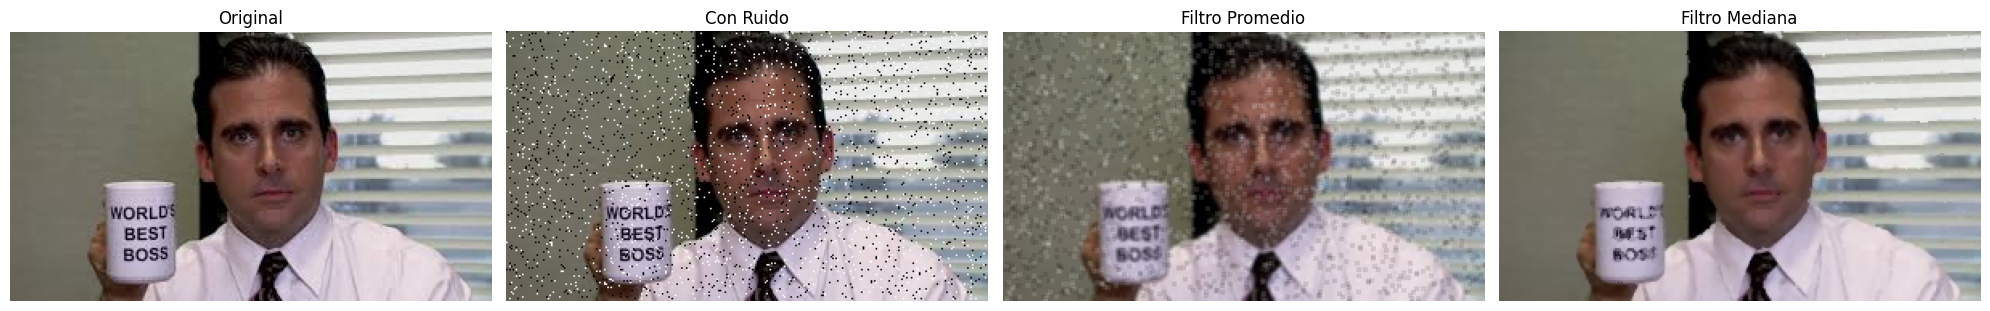

In [3]:
# Función para añadir ruido (sal y pimienta)
def add_salt_pepper_noise(image, salt_prob=0.02, pepper_prob=0.02):
    noisy_image = image.copy()
    total_pixels = image.shape[0] * image.shape[1]

    # Añadir sal (píxeles blancos)
    num_salt = int(total_pixels * salt_prob)
    coords = [np.random.randint(0, i - 1, num_salt) for i in image.shape[:2]]
    noisy_image[coords[0], coords[1]] = [255, 255, 255]

    # Añadir pimienta (píxeles negros)
    num_pepper = int(total_pixels * pepper_prob)
    coords = [np.random.randint(0, i - 1, num_pepper) for i in image.shape[:2]]
    noisy_image[coords[0], coords[1]] = [0, 0, 0]

    return noisy_image

# Aplicar ruido a la imagen
noisy_image = add_salt_pepper_noise(image, salt_prob=0.03, pepper_prob=0.03)

# Aplicar filtro promedio (1º Forma)
average_filtered = cv2.blur(noisy_image, (3, 3))

# apply the 3x3 mean filter on the image (2º Forma)
# kernel = np.ones((3,3),np.float32)/9
# average_filtered = cv2.filter2D(noisy_image,-1,kernel)

# Aplicar filtro mediana 3x3
median_filtered = cv2.medianBlur(noisy_image, 3)

# Mostrar las imágenes
titles = ['Original', 'Con Ruido', 'Filtro Promedio', 'Filtro Mediana']
images = [image, noisy_image, average_filtered, median_filtered]

plt.figure(figsize=(20, 5))
for i in range(4):
    plt.subplot(1, 4, i + 1)
    plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

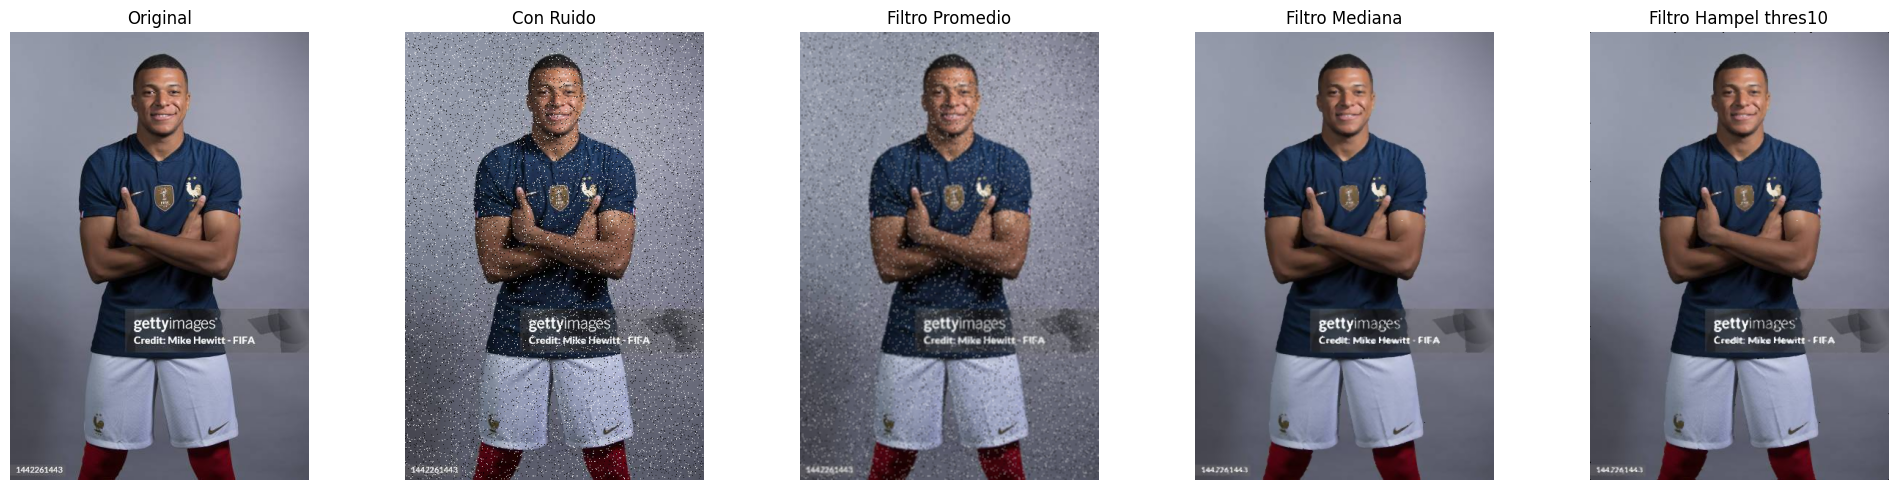

In [ ]:
# Función de filtro de Hampel
def hampel_filter(image, window_size=3, threshold=1):
    padded_image = np.pad(image, ((window_size//2, window_size//2), (window_size//2, window_size//2), (0, 0)), mode='constant')
    filtered_image = image.copy()

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            # Extraer la ventana del píxel actual
            window = padded_image[i:i+window_size, j:j+window_size]
            median = np.median(window, axis=(0, 1))  # Mediana de la ventana
            diff = np.abs(window - median)  # Diferencia entre el píxel y la mediana

            # Si la diferencia excede el umbral, sustituir por la mediana
            if np.any(diff > threshold):
                filtered_image[i, j] = median

    return filtered_image


# Aplicar filtro de Hampel
threshold=10
hampel_filtered = hampel_filter(noisy_image, window_size=3, threshold=threshold)

# Mostrar las imágenes
titles = ['Original', 'Con Ruido', 'Filtro Promedio', 'Filtro Mediana', f'Filtro Hampel thres{threshold}']
images = [image, noisy_image, average_filtered, median_filtered, hampel_filtered]

plt.figure(figsize=(20, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

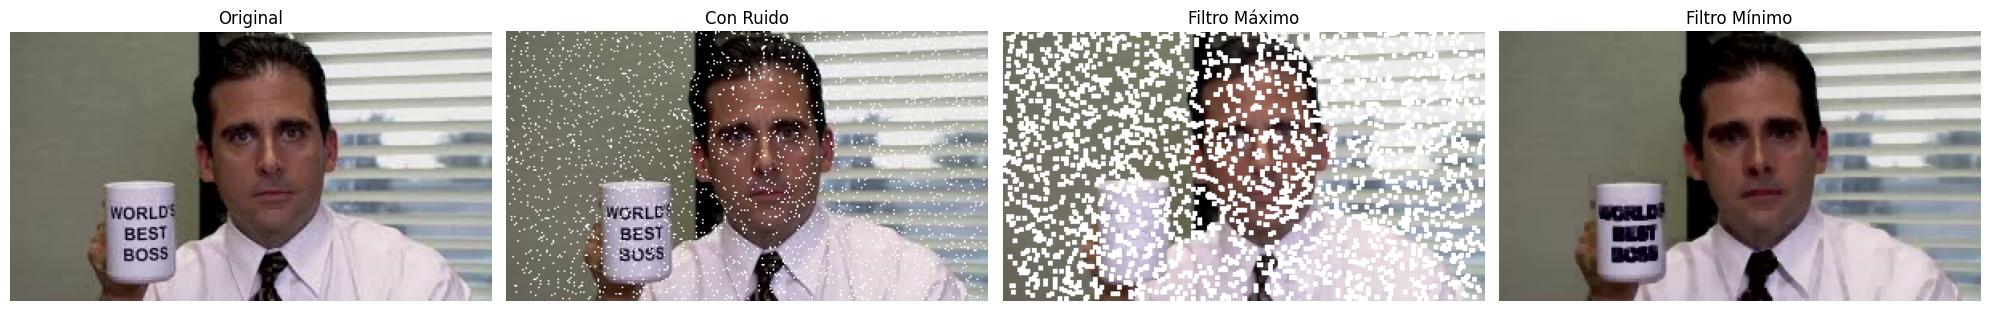

In [ ]:
 # Aplicar ruido a la imagen
noisy_image = add_salt_pepper_noise(image, salt_prob=0.05, pepper_prob=0.00)

# Filtro máximo: aumenta el tamaño de las formas o regiones blancas (255) y reduce las áreas oscuras (0) en una imagen binaria.
def maximum_filter(image, kernel_size_r=3, kernel_size_c=3):
    return cv2.dilate(image, np.ones((kernel_size_r, kernel_size_c)))

# Filtro mínimo: La erosión reduce el tamaño de las formas o regiones blancas en una imagen binaria (píxeles de valor 255) y expande las áreas oscuras (píxeles de valor 0).
def minimum_filter(image, kernel_size_r=3, kernel_size_c=3):
    return cv2.erode(image, np.ones((kernel_size_r, kernel_size_c)))

# Aplicar los filtros solicitados
maximum_filtered = maximum_filter(noisy_image,3,3)
minimum_filtered = minimum_filter(noisy_image,3,3)

# Mostrar los filtros adicionales
titles2 = ['Original', 'Con Ruido', 'Filtro Máximo', 'Filtro Mínimo']
images2 = [image, noisy_image, maximum_filtered, minimum_filtered]

plt.figure(figsize=(20, 5))
for i in range(4):
    plt.subplot(1,4, i + 1)
    plt.imshow(cv2.cvtColor(images2[i], cv2.COLOR_BGR2RGB))
    plt.title(titles2[i])
    plt.axis('off')

plt.tight_layout()
plt.show()
